In [1]:
from pathlib import Path

NOTEBOOK_ROOT = Path().resolve()
DATA_DIR = NOTEBOOK_ROOT / "data"

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from scripts.hgt import (
    get_cluster_to_magcount,
    get_hgt_scores,
    plot_ED_vs_HGT,
    plot_ED_vs_GProportion,
    split_hgt_by_ED_and_Gscore,
    get_unique_taxa_hgt,
    HGT_weight_taxa_removed,
    line_and_bar_dualaxes_plot,
)


In [2]:
# Ensure DATA_DIR exists before loading files
if not DATA_DIR.exists():
    print(f"DATA_DIR not found: {DATA_DIR}")
    print("If the archive is available, unzip data.tar.bz2 in the project root.")
    print("Otherwise set DATA_DIR manually to the folder containing the data files, e.g., DATA_DIR = Path('/path/to/data')")


In [3]:
# Load cluster validity: only the habitat clusters with >= mag_count_threshold are valid
cluster_to_magcount_filename = DATA_DIR / 'cluster_to_MAG_count.tsv'
clusterpair_info_filename = DATA_DIR / 'cluster_pair_info_table.tsv'
cotransfer_filename = DATA_DIR / 'cotranfer_annotation.tsv'
HGT_result_filename = DATA_DIR / 'HGT_genomepair.tsv'

cotransfer_info_df = pd.read_csv(cotransfer_filename, sep='\t')
clusterpair_info_df = pd.read_csv(clusterpair_info_filename, sep='\t')
cluster_to_magcount = get_cluster_to_magcount(cluster_to_magcount_filename)

## Total HGT count and normalized score

In [4]:
total_cotransfer_indexes = set(cotransfer_info_df['co-transfer_index'])
total_HGT_df = get_hgt_scores(total_cotransfer_indexes, HGT_result_filename, cluster_to_magcount, mag_count_threshold=1000, scaling_constant=1_000_000)

In [5]:
generalist_involved_cotransfer_indexes = set(
    cotransfer_info_df[cotransfer_info_df['max_generalism_score'] >= 0.1]['co-transfer_index']
    )
generalist_involved_HGT_df = get_hgt_scores(generalist_involved_cotransfer_indexes, HGT_result_filename, cluster_to_magcount, mag_count_threshold=1000, scaling_constant=1_000_000)

In [6]:
hgt_ED_combined = pd.merge(clusterpair_info_df, total_HGT_df, on=['cluster1', 'cluster2'], how='inner')
hgt_ED_combined = pd.merge(hgt_ED_combined, generalist_involved_HGT_df, on=['cluster1', 'cluster2'], how='inner', suffixes=('', '_generalist_involved'))
hgt_ED_combined['proportion_of_generalist_involved_HGT'] =  hgt_ED_combined['normalized_score_generalist_involved'] / hgt_ED_combined['normalized_score']

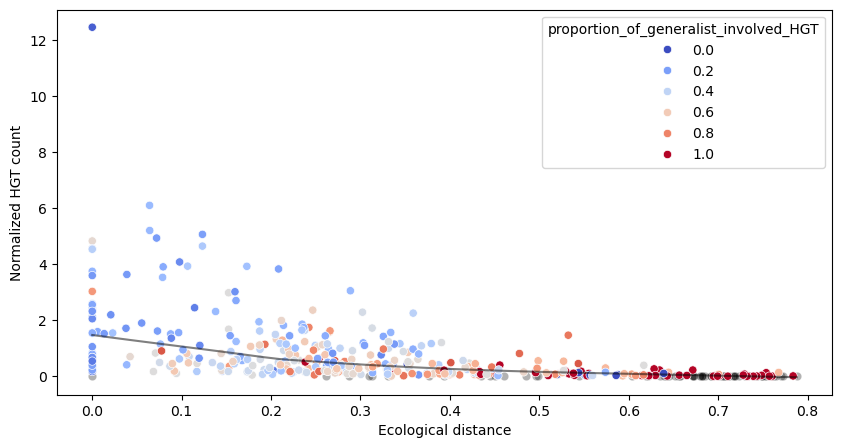

In [7]:
# Figure 5C
plot_ED_vs_HGT(hgt_ED_combined)

Pearson 0.5890416867419441 1.8183636027964535e-35


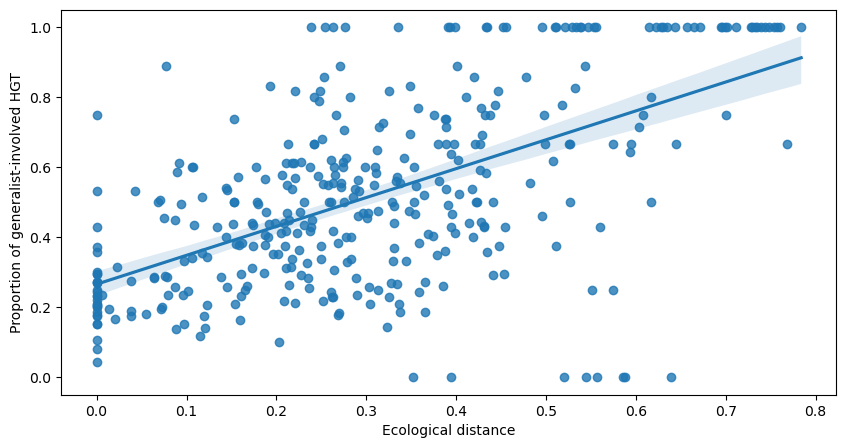

In [8]:
# Figure S6A
plot_ED_vs_GProportion(hgt_ED_combined)

In [9]:
# Get valuds for Figure 5C and Figure 5D
normalized_score_category, by_proportion = split_hgt_by_ED_and_Gscore(
    cotransfer_info_df,
    HGT_result_filename,
    cluster_to_magcount,
    clusterpair_info_df,
    generalism_cutoff=0.1,
    ecological_distance_cutoff=0.5,
)


In [10]:
normalized_score_category

,normalized_score,normalized_score_among_S,normalized_score_between_SG,normalized_score_among_G
disparate_habitat_HGT,,,,
False,286.549885,184.487112,101.732091,0.330681
True,6.999791,1.764169,5.235622,0.000000


In [11]:
by_proportion

,normalized_score_among_S,normalized_score_between_SG,normalized_score_among_G
disparate_habitat_HGT,,,
False,0.643822,0.355024,0.001154
True,0.252032,0.747968,0.000000


## Family removal analysis

In [12]:
unique_HGTs, rank_taxon_to_unique_HGTs = get_unique_taxa_hgt(
    HGT_result_filename,
    cluster_to_magcount,
    taxonomy_path=DATA_DIR / 'GTDBr207_defined_species.txt',
    mag_count_threshold=1000,
    exclude_inferred=False,
)

In [13]:
total_cotransfer_indexes = set(cotransfer_info_df['co-transfer_index'])
total_HGT_df = get_hgt_scores(total_cotransfer_indexes, HGT_result_filename, cluster_to_magcount, mag_count_threshold=1000, scaling_constant=1_000_000)
alltaxa_HGT_merged = total_HGT_df.merge(clusterpair_info_df, on=['cluster1', 'cluster2'], how='left')

In [14]:
alltaxa_HGT_total_weight_sum = alltaxa_HGT_merged['normalized_score'].sum()
alltaxa_HGT_disparate_weight_sum = alltaxa_HGT_merged[alltaxa_HGT_merged['ecological_distance'] >= 0.5]['normalized_score'].sum()

In [15]:
# by removing individual taxon, calculate how much of total and disparate-habitat horizontal gene tranfers are reduced.
# This part will take several hours to calculate, precalculated result can be found 
# ./data/rank_taxon_to_HGT_contribution.tsv
'''
ranks = ['domain','phylum','class','order','family','genus', 'species']

rank_taxon_HGT_contribution_aslist = list()
for rank in ranks:
    taxa = rank_taxon_to_unique_HGTs[rank].keys()
    for taxon in taxa:
        taxon_removed_HGT_weight = HGT_weight_taxa_removed(
            unique_HGTs,
            rank_taxon_to_unique_HGTs[rank],
            {taxon},
            cluster_to_magcount,
            scaling_constant=1_000_000,
            mag_count_threshold=1000,
        )
        taxon_removed_merged = taxon_removed_HGT_weight.merge(clusterpair_info_df, on=['cluster1', 'cluster2'])        
        taxon_removed_total_weight_sum = taxon_removed_merged['normalized_HGT_count'].sum()
        taxon_removed_total_disparate_weight_sum = taxon_removed_merged[taxon_removed_merged['ecological_distance'] >= 0.5]['normalized_HGT_count'].sum()
        
        reduced_rate_total = (alltaxa_HGT_total_weight_sum - taxon_removed_total_weight_sum) / alltaxa_HGT_total_weight_sum
        reduced_rate_disparate = (alltaxa_HGT_disparate_weight_sum - taxon_removed_total_disparate_weight_sum) / alltaxa_HGT_disparate_weight_sum
        
        rank_taxon_HGT_contribution_aslist.append([rank, taxon, reduced_rate_total, reduced_rate_disparate])
            
rank_taxon_to_HGT_contribution_df = pd.DataFrame(rank_taxon_HGT_contribution_aslist, columns = ['rank','taxon','reduced_rate_total_HGT','reduced_rate_disparate_HGT'])
rank_taxon_to_HGT_contribution_df.to_csv('./data/rank_taxon_to_HGT_contribution.tsv', sep="\t", index=False)
'''
rank_taxon_to_HGT_contribution_df = pd.read_csv('./data/rank_taxon_to_HGT_contribution.tsv', sep='\t')


In [16]:
rank = 'family'
top_n = 10

# get [top_n] [rank] taxa with the most contribution to disparate-habiatt HGT
top_taxa =  rank_taxon_to_HGT_contribution_df[rank_taxon_to_HGT_contribution_df['rank'] == rank].sort_values(by='reduced_rate_disparate_HGT', ascending=False).head(top_n)['taxon'].to_list()

In [17]:
#This is to calculate how much diprate-habitat horizontal gene transfer will be reduced by cumulative remonal of top taxa.

result_as_list = [['total', alltaxa_HGT_disparate_weight_sum, 1]]

for i in range(len(top_taxa)):
    removed_taxon = top_taxa[i]
    to_remove_cumulative = set(top_taxa[:i+1])
    taxa_removed_HGT_weight = HGT_weight_taxa_removed(
        unique_HGTs,
        rank_taxon_to_unique_HGTs[rank],
        to_remove_cumulative,
        cluster_to_magcount,
        scaling_constant=1_000_000,
        mag_count_threshold=1000,
    )
    taxa_removed_merged = taxa_removed_HGT_weight.merge(clusterpair_info_df, on=['cluster1', 'cluster2'])
    taxa_removed_total_weight_sum = taxa_removed_merged['normalized_HGT_count'].sum()
    taxa_removed_total_disparate_weight_sum = taxa_removed_merged[taxa_removed_merged['ecological_distance'] >= 0.5]['normalized_HGT_count'].sum()

    result_as_list.append([removed_taxon, taxa_removed_total_disparate_weight_sum, taxa_removed_total_disparate_weight_sum/alltaxa_HGT_disparate_weight_sum])

retained_longD_HGT_df = pd.DataFrame(result_as_list, columns = ['taxon', 'retained_HGT_weight', 'proportion_retained'])


In [18]:
individual_cumulative_merged_df = retained_longD_HGT_df.merge(
    rank_taxon_to_HGT_contribution_df[rank_taxon_to_HGT_contribution_df['taxon'].isin(top_taxa)]
    ,on='taxon',  how='outer')

taxa_order = ['total'] + top_taxa
remaining_taxa = [taxon for taxon in individual_cumulative_merged_df['taxon'].dropna().unique() if taxon not in taxa_order]
taxa_order.extend(remaining_taxa)

individual_cumulative_merged_df['taxon'] = pd.Categorical(individual_cumulative_merged_df['taxon'], categories=taxa_order, ordered=True)
individual_cumulative_merged_df = individual_cumulative_merged_df.sort_values('taxon')


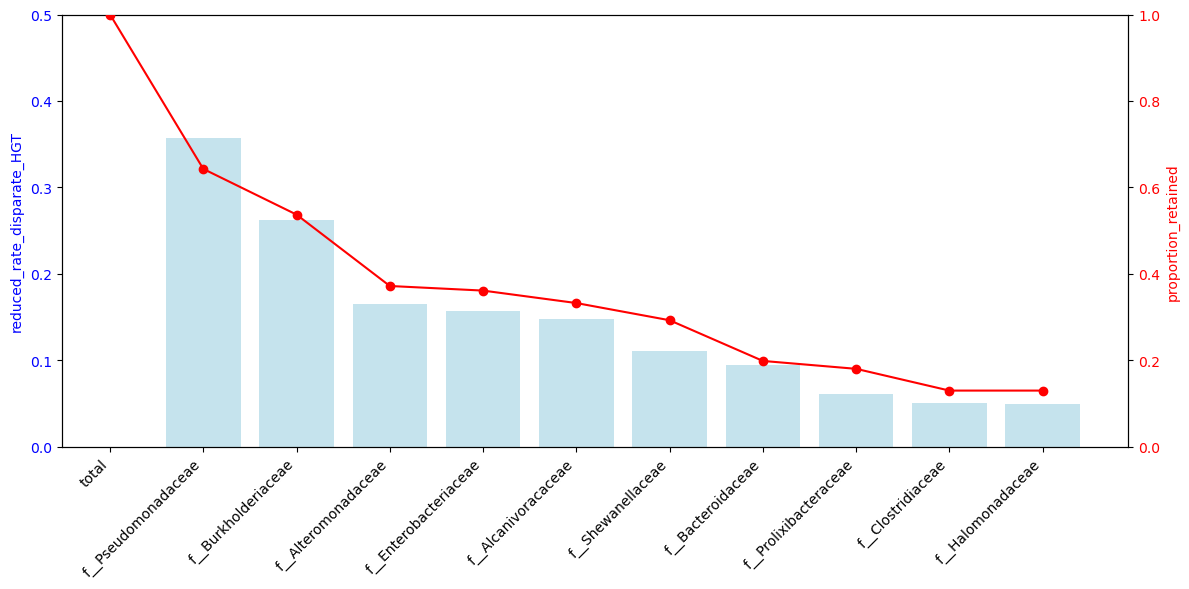

In [19]:
#Figure 5E
line_and_bar_dualaxes_plot(individual_cumulative_merged_df, x_axis='taxon', y_axis1='reduced_rate_disparate_HGT', y_axis2='proportion_retained')

## Antibiotic resistance, Virulence, Defense system genes & Anthropogenic microbiome

In [22]:
habitat_to_category = {
    'HTS':'environmental', 'OLL':'environmental', 'OIL':'environmental', 'OHL':'environmental', 'POL':'environmental',
    'EST':'environmental', 'FRW':'environmental', 'TEH':'environmental', 'TER':'environmental', 'TEG':'environmental',
    'ADC':'host-associated', 'HOR':'host-associated', 'HUV':'host-associated', 'HSS':'host-associated', 'MOG':'host-associated',
    'RMG':'host-associated', 'CKG':'host-associated', 'APG':'host-associated', 'HG1':'host-associated', 'MKG':'host-associated',
    'PG1':'host-associated', 'PG2':'host-associated', 'HG2':'host-associated', 'HG3':'host-associated', 'HG4':'host-associated',
    'HG5':'host-associated', 'HG6':'host-associated', 'HG7':'host-associated','NBG':'host-associated', 'IFG':'host-associated',
    'CDG':'host-associated', 'BG1':'host-associated','BG2':'host-associated', 'BG3':'host-associated','HRG':'host-associated',
    'ANI':'host-associated', 'BLD':'anthropogenic', 'WT1':'anthropogenic', 'WT2':'anthropogenic', 'HET':'anthropogenic'
}

In [23]:
HGT_ED_combined_nonzero = hgt_ED_combined[
    hgt_ED_combined['hgt_count'] != 0
].copy()
HGT_ED_combined_nonzero['cluster1_category'] = HGT_ED_combined_nonzero['cluster1'].map(habitat_to_category)
HGT_ED_combined_nonzero['cluster2_category'] = HGT_ED_combined_nonzero['cluster2'].map(habitat_to_category)
HGT_ED_combined_nonzero = HGT_ED_combined_nonzero[HGT_ED_combined_nonzero['cluster1_category'] != HGT_ED_combined_nonzero['cluster2_category']]
HGT_ED_combined_nonzero['category_pair'] = HGT_ED_combined_nonzero.apply(
    lambda row: "-".join(sorted([habitat_to_category[row['cluster1']], habitat_to_category[row['cluster2']]])),
    axis=1 
)
required_cols = ['cluster1','cluster2','normalized_score','proportion_of_generalist_involved_HGT','category_pair']
HGT_ED_combined_required = HGT_ED_combined_nonzero[required_cols].copy()

In [24]:
target_gene_total_cotransfer_indexes = set(
    cotransfer_info_df[
        (cotransfer_info_df['ARG_count'] >= 1)
        | (cotransfer_info_df['virulence_count'] >= 1)
        | (cotransfer_info_df['defence_count'] >= 1)
    ]['co-transfer_index']
)
target_gene_total_HGT_df = get_hgt_scores(target_gene_total_cotransfer_indexes, HGT_result_filename, cluster_to_magcount, mag_count_threshold=1000, scaling_constant=1_000_000)

In [25]:
target_gene_generalist_involved_cotransfer_indexes = set(
    cotransfer_info_df[
        (
            (cotransfer_info_df["ARG_count"] >= 1)
            | (cotransfer_info_df["virulence_count"] >= 1)
            | (cotransfer_info_df["defence_count"] >= 1)
        )
        & (cotransfer_info_df["max_generalism_score"] >= 0.1)
    ]["co-transfer_index"]
)
target_gene_generalist_involved_HGT_df = get_hgt_scores(target_gene_generalist_involved_cotransfer_indexes, HGT_result_filename, cluster_to_magcount, mag_count_threshold=1000, scaling_constant=1_000_000)


In [26]:
target_gene_hgt_combined = pd.merge(target_gene_total_HGT_df, target_gene_generalist_involved_HGT_df, on=['cluster1', 'cluster2'], suffixes=('', '_generalist_involved'))
target_gene_hgt_combined['proportion_of_generalist_involved_HGT'] = target_gene_hgt_combined['normalized_score_generalist_involved'] / target_gene_hgt_combined['normalized_score']
target_gene_hgt_required = target_gene_hgt_combined[['cluster1','cluster2','normalized_score','proportion_of_generalist_involved_HGT']]

In [27]:
result_df = pd.merge(HGT_ED_combined_required, target_gene_hgt_required, on=['cluster1', 'cluster2'], how='left', suffixes=('_all_genes', '_target_genes'))

In [28]:
result_df.groupby('category_pair')['normalized_score_all_genes'].mean()

category_pair
anthropogenic-environmental      0.455729
anthropogenic-host-associated    0.418070
environmental-host-associated    0.081092
Name: normalized_score_all_genes, dtype: float64

In [29]:
result_df.groupby('category_pair')['proportion_of_generalist_involved_HGT_all_genes'].mean()

category_pair
anthropogenic-environmental      0.815499
anthropogenic-host-associated    0.581590
environmental-host-associated    0.730937
Name: proportion_of_generalist_involved_HGT_all_genes, dtype: float64

In [30]:
result_df.groupby('category_pair')['normalized_score_target_genes'].mean()

category_pair
anthropogenic-environmental      0.137298
anthropogenic-host-associated    0.223348
environmental-host-associated    0.032441
Name: normalized_score_target_genes, dtype: float64

In [31]:
result_df.groupby('category_pair')['proportion_of_generalist_involved_HGT_target_genes'].mean()

category_pair
anthropogenic-environmental      0.768889
anthropogenic-host-associated    0.771806
environmental-host-associated    0.918917
Name: proportion_of_generalist_involved_HGT_target_genes, dtype: float64